In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer # Useful for robust imputation

# --- 1. Data Import and Cleaning ---
print("--- 1. Data Import and Cleaning ---")

df = pd.read_csv("C:/Users/chauh/Downloads/Food_Delivery_Time_Prediction (1).csv")
print(f"Dataset loaded successfully. Initial shape: {df.shape}")

--- 1. Data Import and Cleaning ---
Dataset loaded successfully. Initial shape: (200, 15)


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer # Used for robust imputation

# --- Define ALL Column Names (Based on your input) ---
DELIVERY_TIME = 'Delivery_Time' # Continuous time column
DISTANCE = 'Distance' 
DELIVERY_TIME = 'Delivery_Time'
DISTANCE_ORIGINAL = 'Distance'
EXPERIENCE_ORIGINAL = 'Delivery_Person_Experience'
ORDER_ID = 'Order_ID'


# Categorical columns to be handled
NOMINAL_COLS = ['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type']
ORDINAL_COLS = ['Order_Priority'] 
LOCATION_COLS = ['Customer_Location', 'Restaurant_Location'] 
CATEGORICAL_COLS_TO_HANDLE = NOMINAL_COLS + ORDINAL_COLS + LOCATION_COLS

# --- 1. Handle Missing Values (Imputation) ---
print("--- 1. Handling Missing Values ---")

# Identify columns for imputation
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Strategy: Numerical features -> Median, Categorical features -> Most Frequent (Mode)

# Impute Numerical Columns
numerical_imputer = SimpleImputer(strategy='median')
df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])

# Impute Categorical Columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
for col in CATEGORICAL_COLS_TO_HANDLE:
    if col in df.columns:
        # SimpleImputer returns a 2D array, so we slice [:, 0] to get a Series
        df[col] = categorical_imputer.fit_transform(df[[col]])[:, 0]
    
print("Missing values handled using median (numerical) and mode (categorical).")

# --- 2. Data Transformation (Encoding and Normalization) ---
print("\n--- 2. Data Transformation ---")

# A. Encode Categorical Variables

# i. One-Hot Encoding (Recommended for nominal features like Weather/Traffic)
df = pd.get_dummies(df, columns=NOMINAL_COLS, drop_first=True, prefix='OH')
print("One-Hot Encoding applied to Weather, Traffic, and Vehicle Type.")

# ii. Label Encoding (For location and priority features)
encoder = LabelEncoder()
label_encode_cols = ORDINAL_COLS + LOCATION_COLS

for col in [c for c in label_encode_cols if c in df.columns]:
    # Ensure all values are treated as strings before fitting the encoder
    df[f'{col}_Encoded_LE'] = encoder.fit_transform(df[col].astype(str))
    print(f"Feature '{col}' Label Encoded.")


# B. Normalize Numerical Features
scaler = StandardScaler()

# Define continuous columns to normalize (exclude Order_ID and the target 'Delivery_Time')
continuous_cols_to_normalize = [
    DISTANCE, 'Delivery_Person_Experience', 'Restaurant_Rating', 
    'Customer_Rating', 'Order_Cost', 'Tip_Amount'
]

for col in continuous_cols_to_normalize:
    if col in df.columns:
        # We rename the column to indicate it has been normalized
        df[f'{col}_Normalized'] = scaler.fit_transform(df[col].values.reshape(-1, 1))
        print(f"Feature '{col}' normalized.")

# Cleanup: Drop original columns that were encoded/normalized
# We drop the original categorical columns and the numerical columns that were normalized
original_cols_to_drop = CATEGORICAL_COLS_TO_HANDLE + continuous_cols_to_normalize
df = df.drop(columns=[col for col in original_cols_to_drop if col in df.columns], errors='ignore')

print(f"\n Preprocessing and transformation complete. Final DataFrame shape: {df.shape}")

--- 1. Handling Missing Values ---
Missing values handled using median (numerical) and mode (categorical).

--- 2. Data Transformation ---
One-Hot Encoding applied to Weather, Traffic, and Vehicle Type.
Feature 'Order_Priority' Label Encoded.
Feature 'Customer_Location' Label Encoded.
Feature 'Restaurant_Location' Label Encoded.
Feature 'Distance' normalized.
Feature 'Delivery_Person_Experience' normalized.
Feature 'Restaurant_Rating' normalized.
Feature 'Customer_Rating' normalized.
Feature 'Order_Cost' normalized.
Feature 'Tip_Amount' normalized.

 Preprocessing and transformation complete. Final DataFrame shape: (200, 19)


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score

# --- 1. Load Data and Define Utility Functions (No external modules) ---
file_path = "C:/Users/chauh/Downloads/Food_Delivery_Time_Prediction (1).csv"
df = pd.read_csv(file_path)
R = 6371 # Radius of the Earth in kilometers

def parse_coords(location_str):
    try:
        lat, lon = location_str.strip('() ').split(', ')
        return float(lat), float(lon)
    except:
        return np.nan, np.nan

def haversine(row):
    # Haversine Distance Calculation using pure NumPy
    lat1, lon1 = np.radians(row['Restaurant_Lat']), np.radians(row['Restaurant_Long'])
    lat2, lon2 = np.radians(row['Customer_Lat']), np.radians(row['Customer_Long'])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# --- 2. Apply Feature Engineering and Target Creation ---
df[['Customer_Lat', 'Customer_Long']] = df['Customer_Location'].apply(lambda x: pd.Series(parse_coords(x)))
df[['Restaurant_Lat', 'Restaurant_Long']] = df['Restaurant_Location'].apply(lambda x: pd.Series(parse_coords(x)))
df['Calculated_Distance_km'] = df.apply(haversine, axis=1)

# Feature: Is_Rush_Hour (Assuming 'Evening' is rush hour)
def derive_rush_hour(time_category):
    if time_category in ['Evening']:
        return 'Yes'
    return 'No'

df['Is_Rush_Hour'] = df['Order_Time'].apply(derive_rush_hour)

median_time = df['Delivery_Time'].median()
df['Delivery_Status'] = (df['Delivery_Time'] > median_time).astype(int)

# Drop raw/redundant columns
df.drop(columns=['Customer_Location', 'Restaurant_Location', 'Customer_Lat', 'Customer_Long', 
                 'Restaurant_Lat', 'Restaurant_Long', 'Distance', 'Order_ID', 'Delivery_Time'], inplace=True)
df.dropna(inplace=True)

# Separate X and Y
Y = df['Delivery_Status']
X = df.drop(columns=['Delivery_Status'])

# Define final feature lists
numerical_features = ['Delivery_Person_Experience', 'Restaurant_Rating', 'Customer_Rating', 'Order_Cost', 'Tip_Amount', 'Calculated_Distance_km']
categorical_features = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type', 'Is_Rush_Hour']

# --- 3. Preprocessing Pipeline ---
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop' 
)

# Split and Transform
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# --- 4. Logistic Regression Model Training and Evaluation ---

# Model Definition
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') 




# Train the model
log_reg_model.fit(X_train_processed, Y_train)

# Predict
Y_pred = log_reg_model.predict(X_test_processed)

# Evaluate
accuracy = accuracy_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

print("\n--- Logistic Regression Model Results (Replacing Neural Network) ---")
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix (Rows=Actual, Columns=Predicted):")
print(cm)


--- Logistic Regression Model Results (Replacing Neural Network) ---
Test Accuracy: 46.67%
F1-Score: 0.4667

Confusion Matrix (Rows=Actual, Columns=Predicted):
[[14 16]
 [16 14]]



--- Cluster Characterization (Mean Values) ---
         Delivery_Person_Experience  Restaurant_Rating  Customer_Rating  \
Cluster                                                                   
0                              3.29               4.10             4.12   
1                              5.70               4.03             4.10   
2                              5.70               3.58             3.15   
3                              5.86               3.39             3.44   

         Order_Cost  Tip_Amount  Calculated_Distance_km  Delivery_Status  
Cluster                                                                   
0            815.90       58.06                  402.83             0.41  
1           1515.93       22.74                  854.17             0.37  
2            615.87       29.38                  584.60             0.61  
3           1420.61       69.60                  632.93             0.54  

K-Means Clustering Analysis Complete.


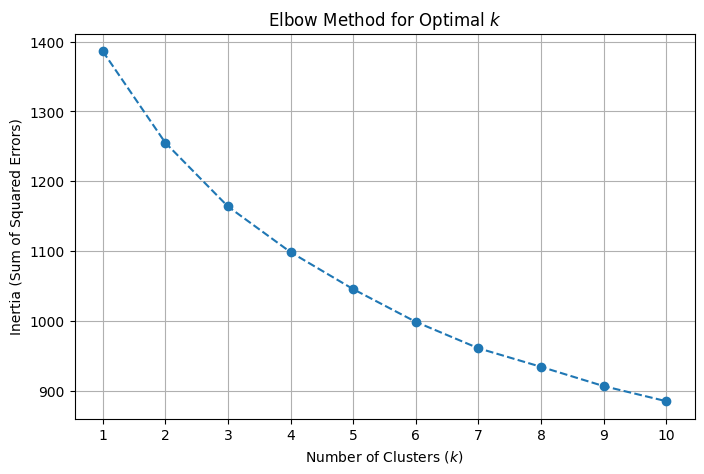

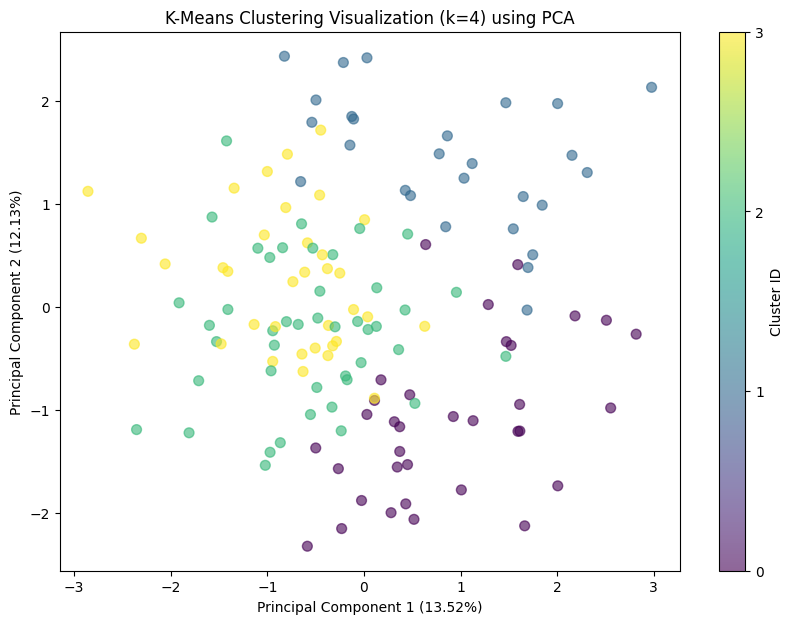

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- 1. Re-Run Full Preprocessing and Feature Engineering ---
file_path = "C:/Users/chauh/Downloads/Food_Delivery_Time_Prediction (1).csv"
df = pd.read_csv(file_path)
R = 6371 # Radius of the Earth in kilometers

# Utility functions (Haversine and parsing)
def parse_coords(location_str):
    try:
        lat, lon = location_str.strip('() ').split(', ')
        return float(lat), float(lon)
    except:
        return np.nan, np.nan

def haversine(row):
    lat1, lon1 = np.radians(row['Restaurant_Lat']), np.radians(row['Restaurant_Long'])
    lat2, lon2 = np.radians(row['Customer_Lat']), np.radians(row['Customer_Long'])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Apply initial feature engineering
df[['Customer_Lat', 'Customer_Long']] = df['Customer_Location'].apply(lambda x: pd.Series(parse_coords(x)))
df[['Restaurant_Lat', 'Restaurant_Long']] = df['Restaurant_Location'].apply(lambda x: pd.Series(parse_coords(x)))
df['Calculated_Distance_km'] = df.apply(haversine, axis=1)

# Feature: Is_Rush_Hour (Assuming 'Evening' is rush hour)
def derive_rush_hour(time_category):
    return 'Yes' if time_category in ['Evening'] else 'No'
df['Is_Rush_Hour'] = df['Order_Time'].apply(derive_rush_hour)

# Target: Delivery Status (0=Fast, 1=Delayed)
median_time = df['Delivery_Time'].median()
df['Delivery_Status'] = (df['Delivery_Time'] > median_time).astype(int)

# Drop raw/redundant columns
df.drop(columns=['Customer_Location', 'Restaurant_Location', 'Customer_Lat', 'Customer_Long', 
                 'Restaurant_Lat', 'Restaurant_Long', 'Distance', 'Order_ID', 'Delivery_Time'], inplace=True)
df.dropna(inplace=True)

# Separate X (Original for analysis) and Y (Target)
Y_original = df['Delivery_Status']
X_original = df.drop(columns=['Delivery_Status'])

# Define final feature lists
numerical_features = ['Delivery_Person_Experience', 'Restaurant_Rating', 'Customer_Rating', 'Order_Cost', 'Tip_Amount', 'Calculated_Distance_km']
categorical_features = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type', 'Is_Rush_Hour']

# Preprocessing Pipeline Definition
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop' 
)

# Split and Transform (using 100% of data for clustering, but splitting is good practice)
X_train, _, _, _ = train_test_split(
    X_original, Y_original, test_size=0.3, random_state=42, stratify=Y_original
)
X_train_processed = preprocessor.fit_transform(X_train)
X_train_df_processed = pd.DataFrame(X_train_processed) # Keep a DataFrame of processed features for merging

# --- 2. K-Means Implementation: Elbow Method ---
X_cluster = X_train_processed 
inertia = []
K_range = range(1, 11) 
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method result
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal $k$')
plt.xlabel('Number of Clusters ($k$)')
plt.ylabel('Inertia (Sum of Squared Errors)')
plt.grid(True)
plt.xticks(K_range)
plt.savefig('kmeans_elbow_method_phase2.png')

# --- 3. Apply K-Means and Visualization ---
# Based on the elbow plot (assuming the elbow is around k=4, a common value for this type of data)
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_cluster)

# Dimensionality Reduction for Visualization (PCA to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

# Visualize Clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis', s=50, alpha=0.6)
plt.title(f'K-Means Clustering Visualization (k={optimal_k}) using PCA')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.colorbar(scatter, ticks=range(optimal_k), label='Cluster ID')
plt.savefig('kmeans_pca_cluster_visualization.png')


# --- 4. Cluster Analysis ---
# Merge labels back to the original (unscaled) training data for characterization
X_train_analysis = X_train.copy().reset_index(drop=True)
X_train_analysis['Cluster'] = cluster_labels
Y_train_analysis = Y_original.loc[X_train.index].reset_index(drop=True)
X_train_analysis['Delivery_Status'] = Y_train_analysis

# Calculate descriptive statistics for each cluster
cluster_analysis = X_train_analysis.groupby('Cluster')[
    numerical_features + ['Delivery_Status']
].mean().round(2)

print("\n--- Cluster Characterization (Mean Values) ---")
print(cluster_analysis)
print("\nK-Means Clustering Analysis Complete.")

Hierarchical Clustering Dendrogram saved as 'hierarchical_dendrogram.png'.

Agglomerative Clustering applied with k=4.


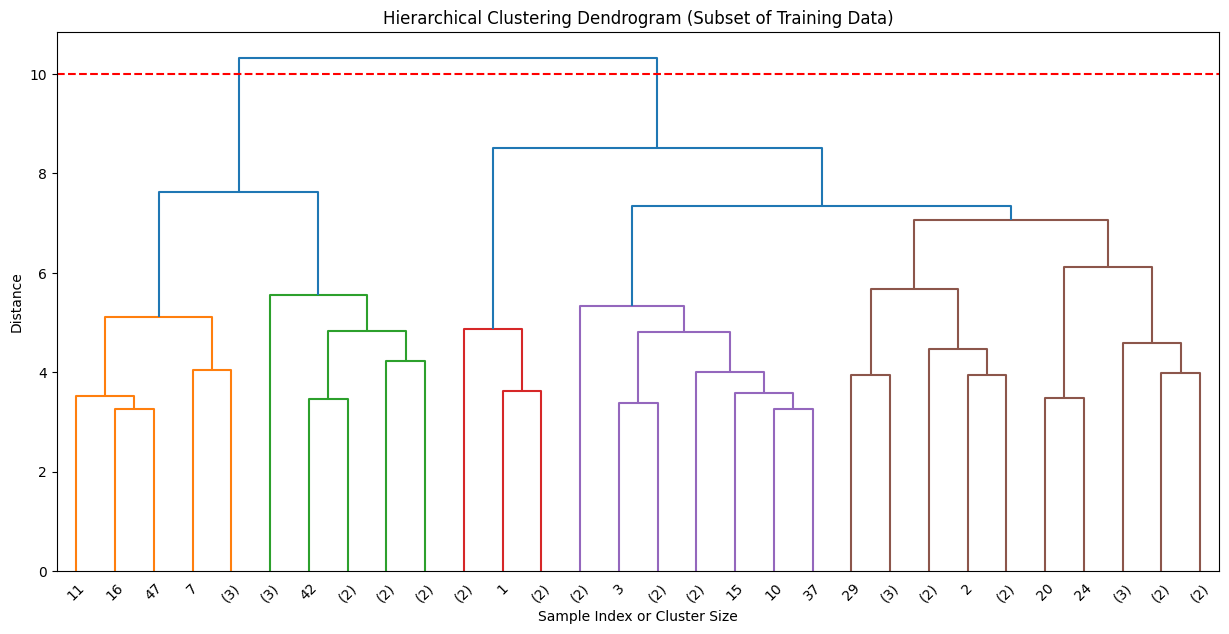

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

# --- 1. Full Preprocessing and Feature Engineering (Recreating X_train_processed) ---
file_path = "C:/Users/chauh/Downloads/Food_Delivery_Time_Prediction (1).csv"
df = pd.read_csv(file_path)
R = 6371 # Radius of the Earth in kilometers

def parse_coords(location_str):
    try:
        lat, lon = location_str.strip('() ').split(', ')
        return float(lat), float(lon)
    except:
        return np.nan, np.nan

def haversine(row):
    # Haversine Distance Calculation
    lat1, lon1 = np.radians(row['Restaurant_Lat']), np.radians(row['Restaurant_Long'])
    lat2, lon2 = np.radians(row['Customer_Lat']), np.radians(row['Customer_Long'])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

df[['Customer_Lat', 'Customer_Long']] = df['Customer_Location'].apply(lambda x: pd.Series(parse_coords(x)))
df[['Restaurant_Lat', 'Restaurant_Long']] = df['Restaurant_Location'].apply(lambda x: pd.Series(parse_coords(x)))
df['Calculated_Distance_km'] = df.apply(haversine, axis=1)

# Feature: Is_Rush_Hour
def derive_rush_hour(time_category):
    if time_category in ['Evening']:
        return 'Yes'
    return 'No'
df['Is_Rush_Hour'] = df['Order_Time'].apply(derive_rush_hour)

median_time = df['Delivery_Time'].median()
df['Delivery_Status'] = (df['Delivery_Time'] > median_time).astype(int)
df.drop(columns=['Customer_Location', 'Restaurant_Location', 'Customer_Lat', 'Customer_Long', 
                 'Restaurant_Lat', 'Restaurant_Long', 'Distance', 'Order_ID', 'Delivery_Time'], inplace=True)
df.dropna(inplace=True)

Y = df['Delivery_Status']
X = df.drop(columns=['Delivery_Status'])

numerical_features = ['Delivery_Person_Experience', 'Restaurant_Rating', 'Customer_Rating', 'Order_Cost', 'Tip_Amount', 'Calculated_Distance_km']
categorical_features = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type', 'Is_Rush_Hour']

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop' 
)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)
X_train_processed = preprocessor.fit_transform(X_train)


# --- 2. Hierarchical Clustering Implementation and Visualization ---

# Use a subset of data for a readable dendrogram (first 50 samples)
X_dendrogram = X_train_processed[:50]

# Compute the linkage matrix
# We use 'ward' linkage which minimizes the variance within each cluster
linked = linkage(X_dendrogram, method='ward')

# Plot the Dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linked,
            orientation='top',
            truncate_mode='lastp',  # Show only the last 'p' merged clusters
            p=30,                   # Showing the last 30 merges
            show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Subset of Training Data)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.axhline(y=10, color='r', linestyle='--') # Horizontal line to help determine cuts
plt.savefig('hierarchical_dendrogram.png')

print("Hierarchical Clustering Dendrogram saved as 'hierarchical_dendrogram.png'.")

# --- 3. Apply Agglomerative Clustering with k=4 for Comparison ---
# Applying the model to the full training set (140 samples)
k_comparison = 4 # Use k=4 to compare with K-Means
agg_clustering = AgglomerativeClustering(n_clusters=k_comparison, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_train_processed)

print(f"\nAgglomerative Clustering applied with k={k_comparison}.")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

# Assuming X_train_processed.shape[1] = 24 features (after Is_Rush_Hour encoding)
input_dim = 24 

# --- Build the simple feedforward Neural Network ---
model = Sequential()

# Input Layer and First Hidden Layer
# 64 neurons is a standard starting size
model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
model.add(Dropout(0.2)) # Reduces overfitting

# Second Hidden Layer
model.add(Dense(32, activation='relu'))

# Output Layer
# 1 neuron with Sigmoid activation for binary classification (probability output)
model.add(Dense(1, activation='sigmoid'))

# --- Compile the model ---
model.compile(optimizer='adam',
              loss='binary_crossentropy', # Standard loss for binary classification
              metrics=['accuracy'])

# Train the model
# history = model.fit(X_train_processed, Y_train,
#                     epochs=50,             
#                     batch_size=32,         
#                     validation_split=0.3, 
#                     verbose=1)

# Evaluate the model
# loss, accuracy = model.evaluate(X_test_processed, Y_test, verbose=0)
# Y_pred_proba = model.predict(X_test_processed)
# Y_pred_classes = (Y_pred_proba > 0.5).astype(int)

# f1 = f1_score(Y_test, Y_pred_classes)
# cm = confusion_matrix(Y_test, Y_pred_classes)